# IY031 - Visualise SimCLR Embeddings for TF @ Condition

In [1]:
import re
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pycatch22
import torch
from pathlib import Path
from matplotlib.patches import Patch
from IPython.display import display
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from tqdm.auto import tqdm

sys.path.insert(0, str(Path("/home/ianyang/stochastic_simulations/src").resolve()))
from models.ssl_transformer import SSL_Transformer

RANDOM_STATE = 42

# Fixed 6-class selection: Nrg1 and Rtg1 at the 3 glucose conditions used in IY021
FIXED_CLASSES = [
    "Nrg1 @ 0.01% glucose",
    "Nrg1 @ 0.1% glucose",
    "Nrg1 @ 2% glucose (mock/steady)",
    "Rtg1 @ 0.01% glucose",
    "Rtg1 @ 0.1% glucose",
    "Rtg1 @ 2% glucose (mock/steady)",
]

IY031_DIR     = Path("/home/ianyang/stochastic_simulations/experiments/EXP-26-IY031")
IY008_DIR     = Path("/home/ianyang/stochastic_simulations/experiments/EXP-25-IY008")
EXP_DIR       = Path("/home/ianyang/stochastic_simulations/experiments")
SS_DATA_DIR   = IY008_DIR / "4_transformed_exp_time_series"
FULL_DATA_DIR = IY008_DIR / "5_FULL_transformed_exp_time_series"
META_PATH     = IY008_DIR / "old_data_metadata.csv"
META_COLS     = ["id", "group", "experiment"]

EXCLUDED_EXPS = {"18446"}
FILE_RE       = re.compile(r"^(\d+)_.*_group_(.+?)_(GFP|mCherry)_time_series$")
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
plt.rcParams.update({
    "font.family": "sans-serif", "axes.titlesize": 14,
    "axes.labelsize": 12, "xtick.labelsize": 10,
    "ytick.labelsize": 10, "legend.fontsize": 10,
})
sns.set_theme(style="whitegrid", palette="colorblind")
print(f"Device: {DEVICE}")

Device: cuda


/home/ianyang/micromamba/envs/stochastic_sim/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Metadata & Label Lookup

In [2]:
metadata = pd.read_csv(META_PATH)
metadata["exp_id"]   = metadata["exp_id"].astype(str)
metadata["group_id"] = metadata["group_id"].astype(str)

LABEL_LOOKUP = {
    (row.exp_id, row.group_id, row.channel): (row.tf, row.condition)
    for _, row in metadata.iterrows()
}

print(f"Metadata entries: {len(LABEL_LOOKUP)}")
print("Unique TFs:",        sorted(metadata["tf"].unique()))
print("Unique conditions:", sorted(metadata["condition"].unique()))


Metadata entries: 66
Unique TFs: ['Cat8', 'Dot6', 'Maf1', 'Mig1', 'Mig2', 'Msn2', 'Nrg1', 'Rtg1', 'Sfp1', 'Tod6']
Unique conditions: ['0.01% galactose', '0.01% glucose', '0.1% glucose', '2% galactose', '2% glucose (mock/steady)']


## 2. Load Datasets

In [3]:
from utils.experimental_time_series import load_labelled_time_series_csvs
"""Scan data_dir for time-series CSVs; assign TF@condition labels via metadata."""

print("=" * 70)
print(f"STEADY-STATE  ({SS_DATA_DIR.name})")
print("=" * 70)
ss_ts_raw, ss_label_strs = load_labelled_time_series_csvs(
        data_dir=SS_DATA_DIR,
        file_re=FILE_RE,
        label_lookup=LABEL_LOOKUP,
        meta_cols=META_COLS,
        excluded_exps=EXCLUDED_EXPS,
    )

print("=" * 70)
print(f"FULL  ({FULL_DATA_DIR.name})")
print("=" * 70)
full_ts_raw, full_label_strs = load_labelled_time_series_csvs(
        data_dir=FULL_DATA_DIR,
        file_re=FILE_RE,
        label_lookup=LABEL_LOOKUP,
        meta_cols=META_COLS,
        excluded_exps=EXCLUDED_EXPS,
    )


STEADY-STATE  (4_transformed_exp_time_series)
  18360/1106/GFP       -> Mig2 @ 0.1% glucose                            (233 cells, 122 tp)
  18360/1106/mCherry   -> Mig1 @ 0.1% glucose                            (233 cells, 23 tp)
  18360/898/GFP       -> Msn2 @ 0.1% glucose                            (254 cells, 116 tp)
  18360/898/mCherry   -> Mig1 @ 0.1% glucose                            (254 cells, 24 tp)
  18360/900/GFP       -> Mig1 @ 0.1% glucose                            (243 cells, 63 tp)
  18360/900/mCherry   -> Msn2 @ 0.1% glucose                            (243 cells, 178 tp)
  18464/756/GFP       -> Sfp1 @ 2% glucose (mock/steady)                (209 cells, 201 tp)
  18464/756/mCherry   -> Msn2 @ 2% glucose (mock/steady)                (209 cells, 237 tp)
  18464/764/GFP       -> Sfp1 @ 2% glucose (mock/steady)                (202 cells, 178 tp)
  18464/764/mCherry   -> Dot6 @ 2% glucose (mock/steady)                (202 cells, 129 tp)
  18464/903/GFP       -> Dot6 @ 2% 

  19330/1348/mCherry   -> Msn2 @ 2% glucose (mock/steady)                (140 cells, 159 tp)


  19330/1349/GFP       -> Tod6 @ 2% glucose (mock/steady)                (143 cells, 211 tp)


  19330/1349/mCherry   -> Msn2 @ 2% glucose (mock/steady)                (143 cells, 120 tp)
  19391/1345/GFP       -> Mig2 @ 2% galactose                            (95 cells, 247 tp)
  19391/1345/mCherry   -> Msn2 @ 2% galactose                            (95 cells, 65 tp)
  19391/1348/GFP       -> Maf1 @ 2% galactose                            (126 cells, 79 tp)
  19391/1348/mCherry   -> Msn2 @ 2% galactose                            (126 cells, 92 tp)
  19391/1349/GFP       -> Tod6 @ 2% galactose                            (68 cells, 85 tp)
  19391/1349/mCherry   -> Msn2 @ 2% galactose                            (68 cells, 69 tp)
  19392/1106/GFP       -> Mig2 @ 0.01% galactose                         (187 cells, 49 tp)
  19392/1106/mCherry   -> Mig1 @ 0.01% galactose                         (187 cells, 28 tp)
  19392/898/GFP       -> Msn2 @ 0.01% galactose                         (163 cells, 34 tp)
  19392/898/mCherry   -> Mig1 @ 0.01% galactose                         (163 cells,

  20213/1347/GFP       -> Rtg1 @ 0.01% glucose                           (275 cells, 165 tp)


...

  19394/1348/GFP       -> Maf1 @ 0.1% glucose                            (201 cells, 540 tp)
  19394/1348/mCherry   -> Msn2 @ 0.1% glucose                            (201 cells, 540 tp)
  19394/1349/GFP       -> Tod6 @ 0.1% glucose                            (178 cells, 540 tp)
  19394/1349/mCherry   -> Msn2 @ 0.1% glucose                            (178 cells, 540 tp)
  19554/756/GFP       -> Sfp1 @ 0.01% glucose                           (196 cells, 540 tp)
  19554/756/mCherry   -> Msn2 @ 0.01% glucose                           (196 cells, 540 tp)
  19554/900/GFP       -> Mig1 @ 0.01% glucose                           (193 cells, 540 tp)
  19554/900/mCherry   -> Msn2 @ 0.01% glucose                           (193 cells, 540 tp)


  19554/903/GFP       -> Dot6 @ 0.01% glucose                           (170 cells, 540 tp)
  19554/903/mCherry   -> Msn2 @ 0.01% glucose                           (170 cells, 540 tp)


  19566/1344/GFP       -> Cat8 @ 0.1% glucose                            (214 cells, 540 tp)
  19566/1344/mCherry   -> Msn2 @ 0.1% glucose                            (214 cells, 540 tp)
  19566/1346/GFP       -> Nrg1 @ 0.1% glucose                            (231 cells, 540 tp)
  19566/1346/mCherry   -> Msn2 @ 0.1% glucose                            (231 cells, 540 tp)
  19566/1347/GFP       -> Rtg1 @ 0.1% glucose                            (200 cells, 540 tp)
  19566/1347/mCherry   -> Msn2 @ 0.1% glucose                            (200 cells, 540 tp)
  20213/1344/GFP       -> Cat8 @ 0.01% glucose                           (241 cells, 540 tp)


  20213/1344/mCherry   -> Msn2 @ 0.01% glucose                           (241 cells, 540 tp)
  20213/1346/GFP       -> Nrg1 @ 0.01% glucose                           (231 cells, 540 tp)


  20213/1346/mCherry   -> Msn2 @ 0.01% glucose                           (231 cells, 540 tp)
  20213/1347/GFP       -> Rtg1 @ 0.01% glucose                           (275 cells, 540 tp)
  20213/1347/mCherry   -> Msn2 @ 0.01% glucose                           (275 cells, 540 tp)


## 3. Class Selection

In [4]:
def print_class_summary(label_strs, kept_classes, dataset_name):
    counts = pd.Series(label_strs).value_counts().sort_index()
    print(f"{dataset_name} -- {len(counts)} total classes, {len(label_strs)} total cells")
    print(f"  Fixed {len(kept_classes)}-class selection (IY021 sanity check):")
    for cls in sorted(kept_classes):
        cnt = counts.get(cls, 0)
        print(f"  {cls:50s}: {cnt:5d}")
    missing = [c for c in kept_classes if counts.get(c, 0) == 0]
    if missing:
        print(f"  WARNING: missing classes with no data: {missing}")
    print(f"  -> Using {len(kept_classes)} classes")
    print(f"  Chance: 1/{len(kept_classes)} = {1/len(kept_classes):.4f}")
    return list(kept_classes)

ss_kept_classes   = print_class_summary(ss_label_strs,   FIXED_CLASSES, "Steady-state")
full_kept_classes = print_class_summary(full_label_strs, FIXED_CLASSES, "Full")

Steady-state -- 32 total classes, 11980 total cells
  Fixed 6-class selection (IY021 sanity check):
  Nrg1 @ 0.01% glucose                              :   231
  Nrg1 @ 0.1% glucose                               :   231
  Nrg1 @ 2% glucose (mock/steady)                   :    84
  Rtg1 @ 0.01% glucose                              :   275
  Rtg1 @ 0.1% glucose                               :   200
  Rtg1 @ 2% glucose (mock/steady)                   :    78
  -> Using 6 classes
  Chance: 1/6 = 0.1667
Full -- 32 total classes, 11980 total cells
  Fixed 6-class selection (IY021 sanity check):
  Nrg1 @ 0.01% glucose                              :   231
  Nrg1 @ 0.1% glucose                               :   231
  Nrg1 @ 2% glucose (mock/steady)                   :    84
  Rtg1 @ 0.01% glucose                              :   275
  Rtg1 @ 0.1% glucose                               :   200
  Rtg1 @ 2% glucose (mock/steady)                   :    78
  -> Using 6 classes
  Chance: 1/6 = 0.1667


## 4. Preprocessing

In [5]:
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from utils.processing.pipeline import prepare_dataset

print("--- Steady-state ---")
ss = prepare_dataset(ss_ts_raw, ss_label_strs, ss_kept_classes, "Steady-state")
print("--- Full ---")
full = prepare_dataset(full_ts_raw, full_label_strs, full_kept_classes, "Full")

--- Steady-state ---
Steady-state: 1099 cells × 80 tp, 6 classes, NaN remaining: 0
  Balancing to 78 cells/class
  Train: 374  |  Test: 94
--- Full ---
Full: 1099 cells × 540 tp, 6 classes, NaN remaining: 0
  Balancing to 78 cells/class
  Train: 374  |  Test: 94


## 5. Metadata for Balanced Datasets

Reconstruct per-cell metadata (TF, condition, class label) aligned with `X_bal` from the integer labels returned by `prepare_dataset`.

In [6]:
ds_tags = {"Steady-state": "ss", "Full": "full"}
datasets = {"Steady-state": ss, "Full": full}

metadata_dict = {}
for ds_name, ds in datasets.items():
    class_names = ds["class_names"]
    y_bal = ds["y_bal"]
    meta = pd.DataFrame({
        "class_name": [class_names[y] for y in y_bal],
        "label": y_bal,
        "tf": [class_names[y].split(" @ ")[0] for y in y_bal],
        "condition": [class_names[y].split(" @ ")[1] for y in y_bal],
    })
    metadata_dict[ds_name] = meta
    print(f"\n{ds_name}:")
    display(meta["class_name"].value_counts().sort_index().rename("n").to_frame())


Steady-state:


,n
class_name,
Nrg1 @ 0.01% glucose,78
Nrg1 @ 0.1% glucose,78
Nrg1 @ 2% glucose (mock/steady),78
Rtg1 @ 0.01% glucose,78
Rtg1 @ 0.1% glucose,78
Rtg1 @ 2% glucose (mock/steady),78



Full:


,n
class_name,
Nrg1 @ 0.01% glucose,78
Nrg1 @ 0.1% glucose,78
Nrg1 @ 2% glucose (mock/steady),78
Rtg1 @ 0.01% glucose,78
Rtg1 @ 0.1% glucose,78
Rtg1 @ 2% glucose (mock/steady),78


## 6. Feature Extraction

Three representations are extracted per dataset:

- **Raw time-series features**: batch-wise normalised traces scaled with `StandardScaler`.
- **catch22**: 22 canonical time-series features per cell (single channel), scaled.
- **SimCLR**: frozen transformer backbone embeddings from the best IY031 checkpoint (IY023-global b64 D16, acc = 0.30 on steady-state).

A SimCLR + RBF SVM decision-score representation is also computed to visualise classifier-level separation.

In [7]:
from utils.processing.normalisation import batch_wise_normalise
from utils.embeddings import load_simclr_model, encode_channel
from features.catch22 import extract_catch22

# Best overall checkpoint on IY031 steady-state (acc=0.297; IY031_NEW_tf_condition_ss_simclr_results.csv, row 0)
BEST_SIMCLR_CKPT = Path(
    "/home/ianyang/stochastic_simulations/experiments/EXP-26-IY023/"
    "IY023_simCLR_mixed_b64_lr0.01_L2_H4_D16_global_20260315_130449_model.pth"
)
simclr_model = load_simclr_model(BEST_SIMCLR_CKPT, DEVICE)
print(f"Loaded: {BEST_SIMCLR_CKPT.name}\n")

repr_matrices = {ds_name: {} for ds_name in datasets}

for ds_name, ds in datasets.items():
    X_bal = ds["X_bal"]
    X_norm = batch_wise_normalise(X_bal)

    # Raw time-series features (batch-normalised traces as feature vectors)
    repr_matrices[ds_name]["Raw SVM features"] = StandardScaler().fit_transform(X_norm)

    # catch22: 22 canonical time-series features per cell (single channel)
    c22 = extract_catch22(X_bal, desc=f"catch22 {ds_name}", leave=False)
    c22 = c22.fillna(c22.median(numeric_only=True)).fillna(0.0)
    repr_matrices[ds_name]["catch22"] = StandardScaler().fit_transform(c22)

    # SimCLR: frozen single-channel encoder
    Z = encode_channel(simclr_model, X_norm, DEVICE)
    simclr_scaled = StandardScaler().fit_transform(Z)
    repr_matrices[ds_name]["SimCLR"] = simclr_scaled

    # SimCLR + SVM: per-class decision scores from an RBF SVM fitted on SimCLR embeddings
    labels = metadata_dict[ds_name]["label"].to_numpy()
    svm = SVC(kernel="rbf", C=1.0, gamma="scale", decision_function_shape="ovr", random_state=RANDOM_STATE)
    svm.fit(simclr_scaled, labels)
    scores = svm.decision_function(simclr_scaled)
    if scores.ndim == 1:
        scores = scores[:, None]
    repr_matrices[ds_name]["SimCLR + SVM scores"] = StandardScaler().fit_transform(scores)

    sizes = {k: v.shape for k, v in repr_matrices[ds_name].items()}
    print(f"{ds_name}: {sizes}")

Loaded: IY023_simCLR_mixed_b64_lr0.01_L2_H4_D16_global_20260315_130449_model.pth



catch22 Steady-state:   0%|          | 0/468 [00:00<?, ?it/s]

catch22 Steady-state:  61%|██████    | 284/468 [00:00<00:00, 2836.92it/s]

SimCLR encode:   0%|          | 0/2 [00:00<?, ?it/s]

Steady-state: {'Raw SVM features': (468, 80), 'catch22': (468, 22), 'SimCLR': (468, 16), 'SimCLR + SVM scores': (468, 6)}


...

catch22 Full:  77%|███████▋  | 360/468 [00:01<00:00, 351.90it/s]

catch22 Full:  85%|████████▌ | 398/468 [00:01<00:00, 357.75it/s]

catch22 Full:  93%|█████████▎| 434/468 [00:01<00:00, 347.30it/s]

SimCLR encode:   0%|          | 0/2 [00:00<?, ?it/s]

Full: {'Raw SVM features': (468, 540), 'catch22': (468, 22), 'SimCLR': (468, 16), 'SimCLR + SVM scores': (468, 6)}


## 7. Discriminability D Scores and Clustering Metrics

D score (pairwise Cohen's d) measures class separation in the high-dimensional space before projection. ARI and NMI measure how well KMeans clusters (k = 6) align with the known class labels.

In [8]:
from utils.metrics import discriminability_d_score, clustering_agreement_metrics

d_score_dfs = {}
cluster_dfs = {}

for ds_name in datasets:
    labels = metadata_dict[ds_name]["label"].to_numpy()
    tag = ds_tags[ds_name]

    # Discriminability D scores
    d_rows = [
        {"representation": name, **discriminability_d_score(matrix, labels)}
        for name, matrix in repr_matrices[ds_name].items()
    ]
    d_df = pd.DataFrame(d_rows)
    d_score_dfs[ds_name] = d_df
    d_df.to_csv(IY031_DIR / f"IY031_{tag}_embedding_discriminability.csv", index=False)

    # Clustering agreement metrics (KMeans k=6 vs true labels)
    c_rows = [
        {"representation": name, **clustering_agreement_metrics(matrix, labels, RANDOM_STATE)}
        for name, matrix in repr_matrices[ds_name].items()
    ]
    c_df = pd.DataFrame(c_rows)
    cluster_dfs[ds_name] = c_df
    c_df.to_csv(IY031_DIR / f"IY031_{tag}_embedding_clustering_metrics.csv", index=False)

    print(f"\n{'=' * 55}")
    print(f"{ds_name} — Discriminability D scores")
    display(d_df.assign(
        D_score=lambda d: d["D_score"].map(lambda x: f"{x:.2g}"),
        mean_within_distance=lambda d: d["mean_within_distance"].map(lambda x: f"{x:.2g}"),
        mean_between_distance=lambda d: d["mean_between_distance"].map(lambda x: f"{x:.2g}"),
        pooled_distance_sd=lambda d: d["pooled_distance_sd"].map(lambda x: f"{x:.2g}"),
    ))
    print(f"\n{ds_name} — Clustering agreement metrics")
    display(c_df.assign(
        ARI=lambda d: d["ARI"].map(lambda x: f"{x:.2g}"),
        NMI=lambda d: d["NMI"].map(lambda x: f"{x:.2g}"),
        kmeans_inertia=lambda d: d["kmeans_inertia"].map(lambda x: f"{x:.2g}"),
    ))


Steady-state — Discriminability D scores


,representation,D_score,mean_within_distance,mean_between_distance,pooled_distance_sd,n_within_pairs,n_between_pairs
0,Raw SVM features,1.5,4.1,12,5.2,18018,91260
1,catch22,0.2,6,6.4,1.9,18018,91260
2,SimCLR,1.3,2.5,5.5,2.3,18018,91260
3,SimCLR + SVM scores,1.7,1,3.4,1.4,18018,91260



Steady-state — Clustering agreement metrics


,representation,ARI,NMI,n_clusters,kmeans_inertia
0,Raw SVM features,0.43,0.57,6,2.7e+03
1,catch22,0.072,0.12,6,6.2e+03
2,SimCLR,0.32,0.49,6,7.3e+02
3,SimCLR + SVM scores,0.44,0.58,6,81



Full — Discriminability D scores


,representation,D_score,mean_within_distance,mean_between_distance,pooled_distance_sd,n_within_pairs,n_between_pairs
0,Raw SVM features,1.5,12,31,13,18018,91260
1,catch22,0.33,5.6,6.4,2.3,18018,91260
2,SimCLR,1.3,2.6,5.5,2.3,18018,91260
3,SimCLR + SVM scores,1.9,1.1,3.4,1.2,18018,91260



Full — Clustering agreement metrics


,representation,ARI,NMI,n_clusters,kmeans_inertia
0,Raw SVM features,0.49,0.61,6,3e+04
1,catch22,0.17,0.24,6,5.6e+03
2,SimCLR,0.44,0.59,6,1.2e+03
3,SimCLR + SVM scores,0.47,0.6,6,1.7e+02


## 8. Dimensionality Reduction

Three 2-D projections are computed for each representation and dataset:

- **PCA** — deterministic linear projection; fast, captures global variance.
- **t-SNE** — nonlinear neighbourhood embedding; good at revealing local cluster structure.
- **PHATE** — heat-diffusion manifold embedding (Moon et al., 2019); preserves both local and global structure, especially trajectory-like geometry in biological data.

In [9]:
from utils.embeddings import reduce_embeddings

projections = {ds_name: {} for ds_name in datasets}
for ds_name in datasets:
    print(f"\n{ds_name}:")
    for repr_name, matrix in repr_matrices[ds_name].items():
        projections[ds_name][repr_name] = reduce_embeddings(matrix, repr_name, RANDOM_STATE)


Steady-state:
Raw SVM features PCA explained variance: 0.96


    SGD-MDS may not have converged: stress changed by -1.2% in final iterations. Consider increasing n_iter or adjusting learning_rate.


catch22 PCA explained variance: 0.44


    SGD-MDS may not have converged: stress changed by 5.4% in final iterations. Consider increasing n_iter or adjusting learning_rate.


SimCLR PCA explained variance: 0.85


...

catch22 PCA explained variance: 0.50


    SGD-MDS may not have converged: stress changed by -1.4% in final iterations. Consider increasing n_iter or adjusting learning_rate.


SimCLR PCA explained variance: 0.79


SimCLR + SVM scores PCA explained variance: 0.95


/home/ianyang/micromamba/envs/stochastic_sim/lib/python3.11/site-packages/phate/phate.py:919: RuntimeWarning: Graph is disconnected with 15 connected components. This may indicate that your knn parameter (currently 5) is too small, or that your data contains distinct clusters. PHATE may not accurately represent relationships between disconnected components.
  warnings.warn(


## 9. Scatter Plot Visualisation

Each point is one cell. Colour encodes the six TF × condition classes; marker shape separates TF strains (Nrg1 vs Rtg1).

Grid: **rows** = projection method (PCA, t-SNE, PHATE); **columns** = representation (Raw SVM features, catch22, SimCLR, SimCLR + SVM scores). Metric annotations (D score, ARI, NMI) are computed in the high-dimensional space before projection and are identical across all projection rows.

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY031/IY031_ss_embedding_scatter.png


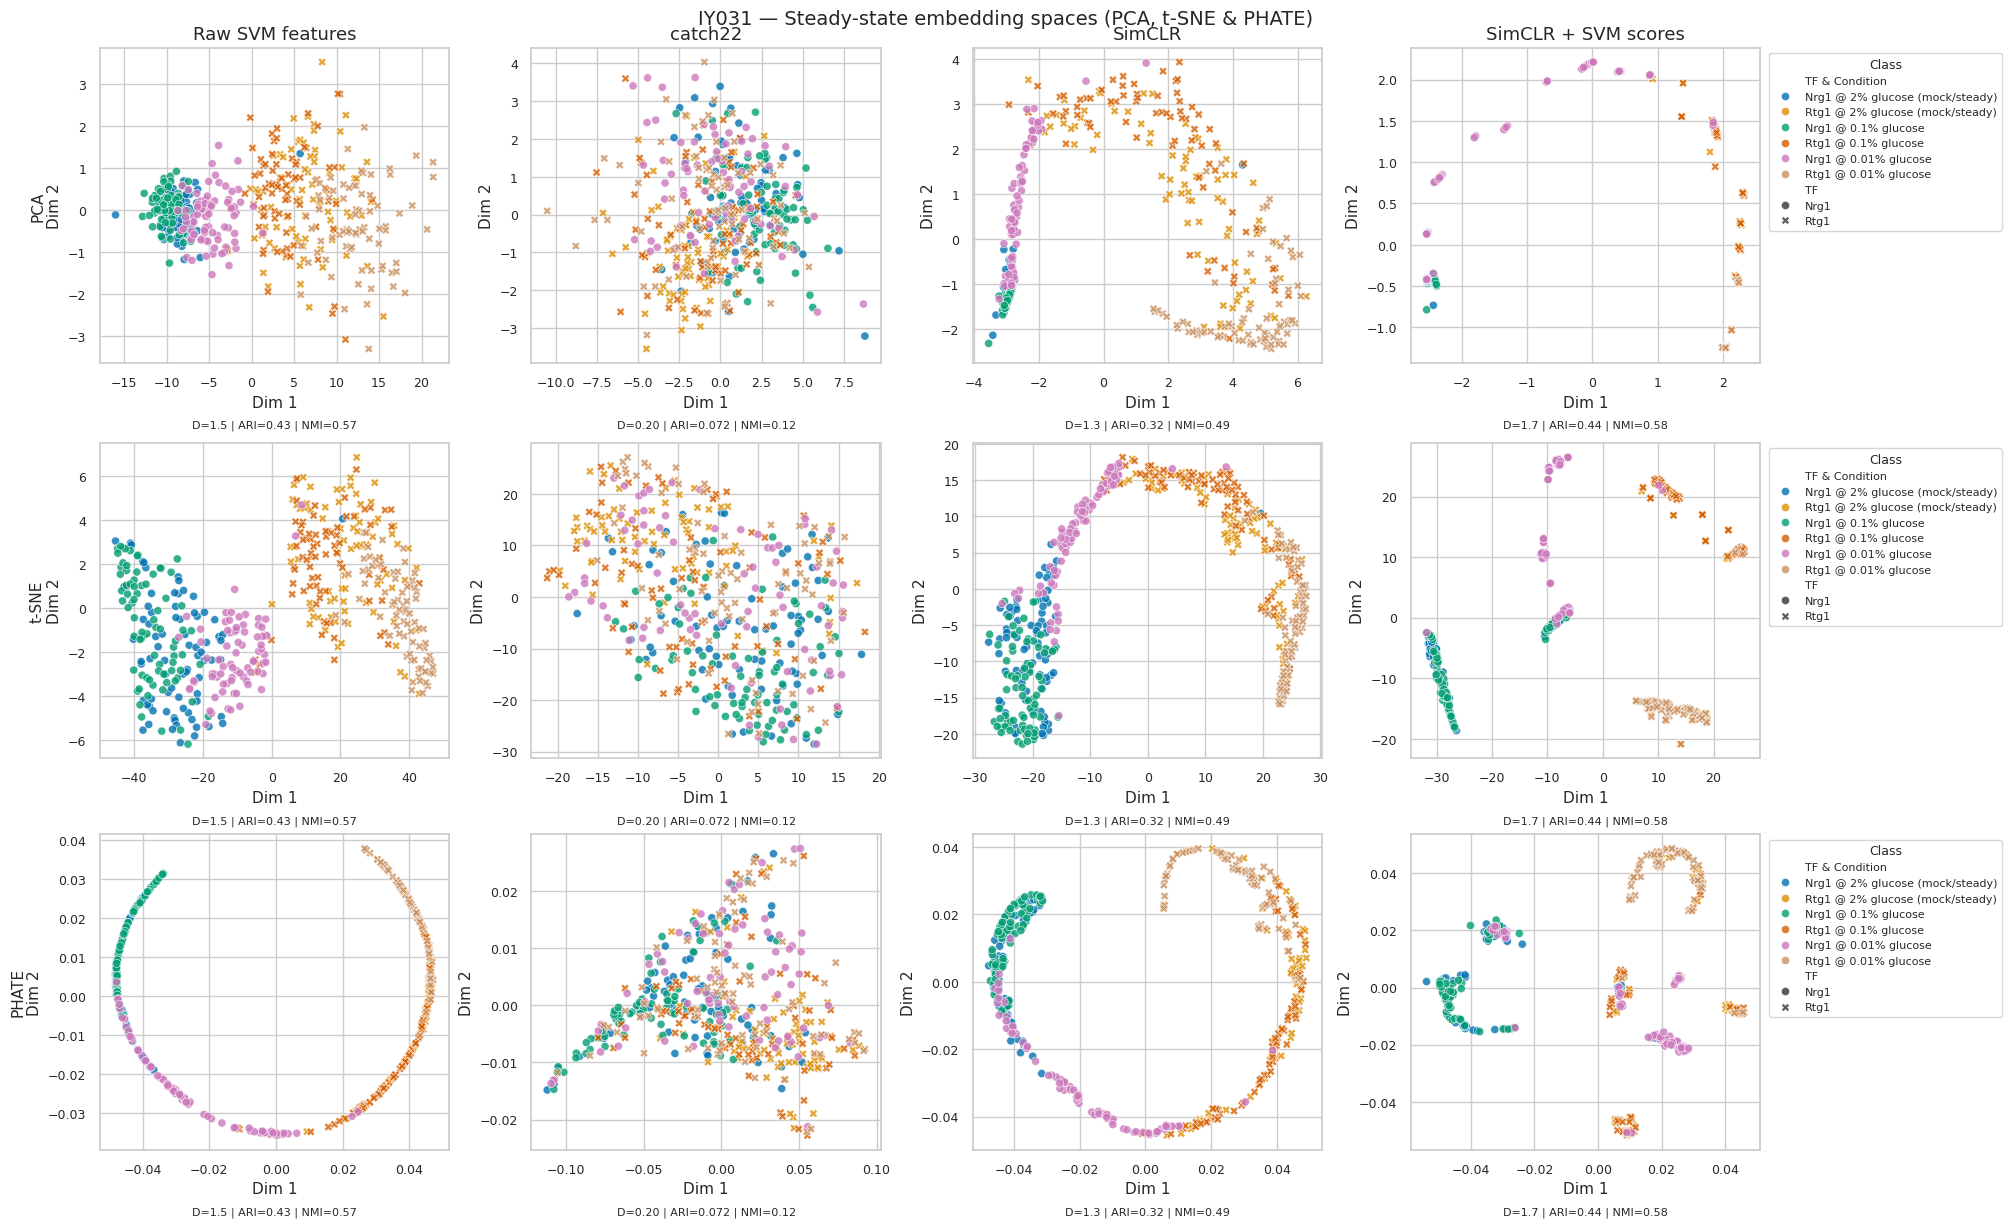

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY031/IY031_full_embedding_scatter.png


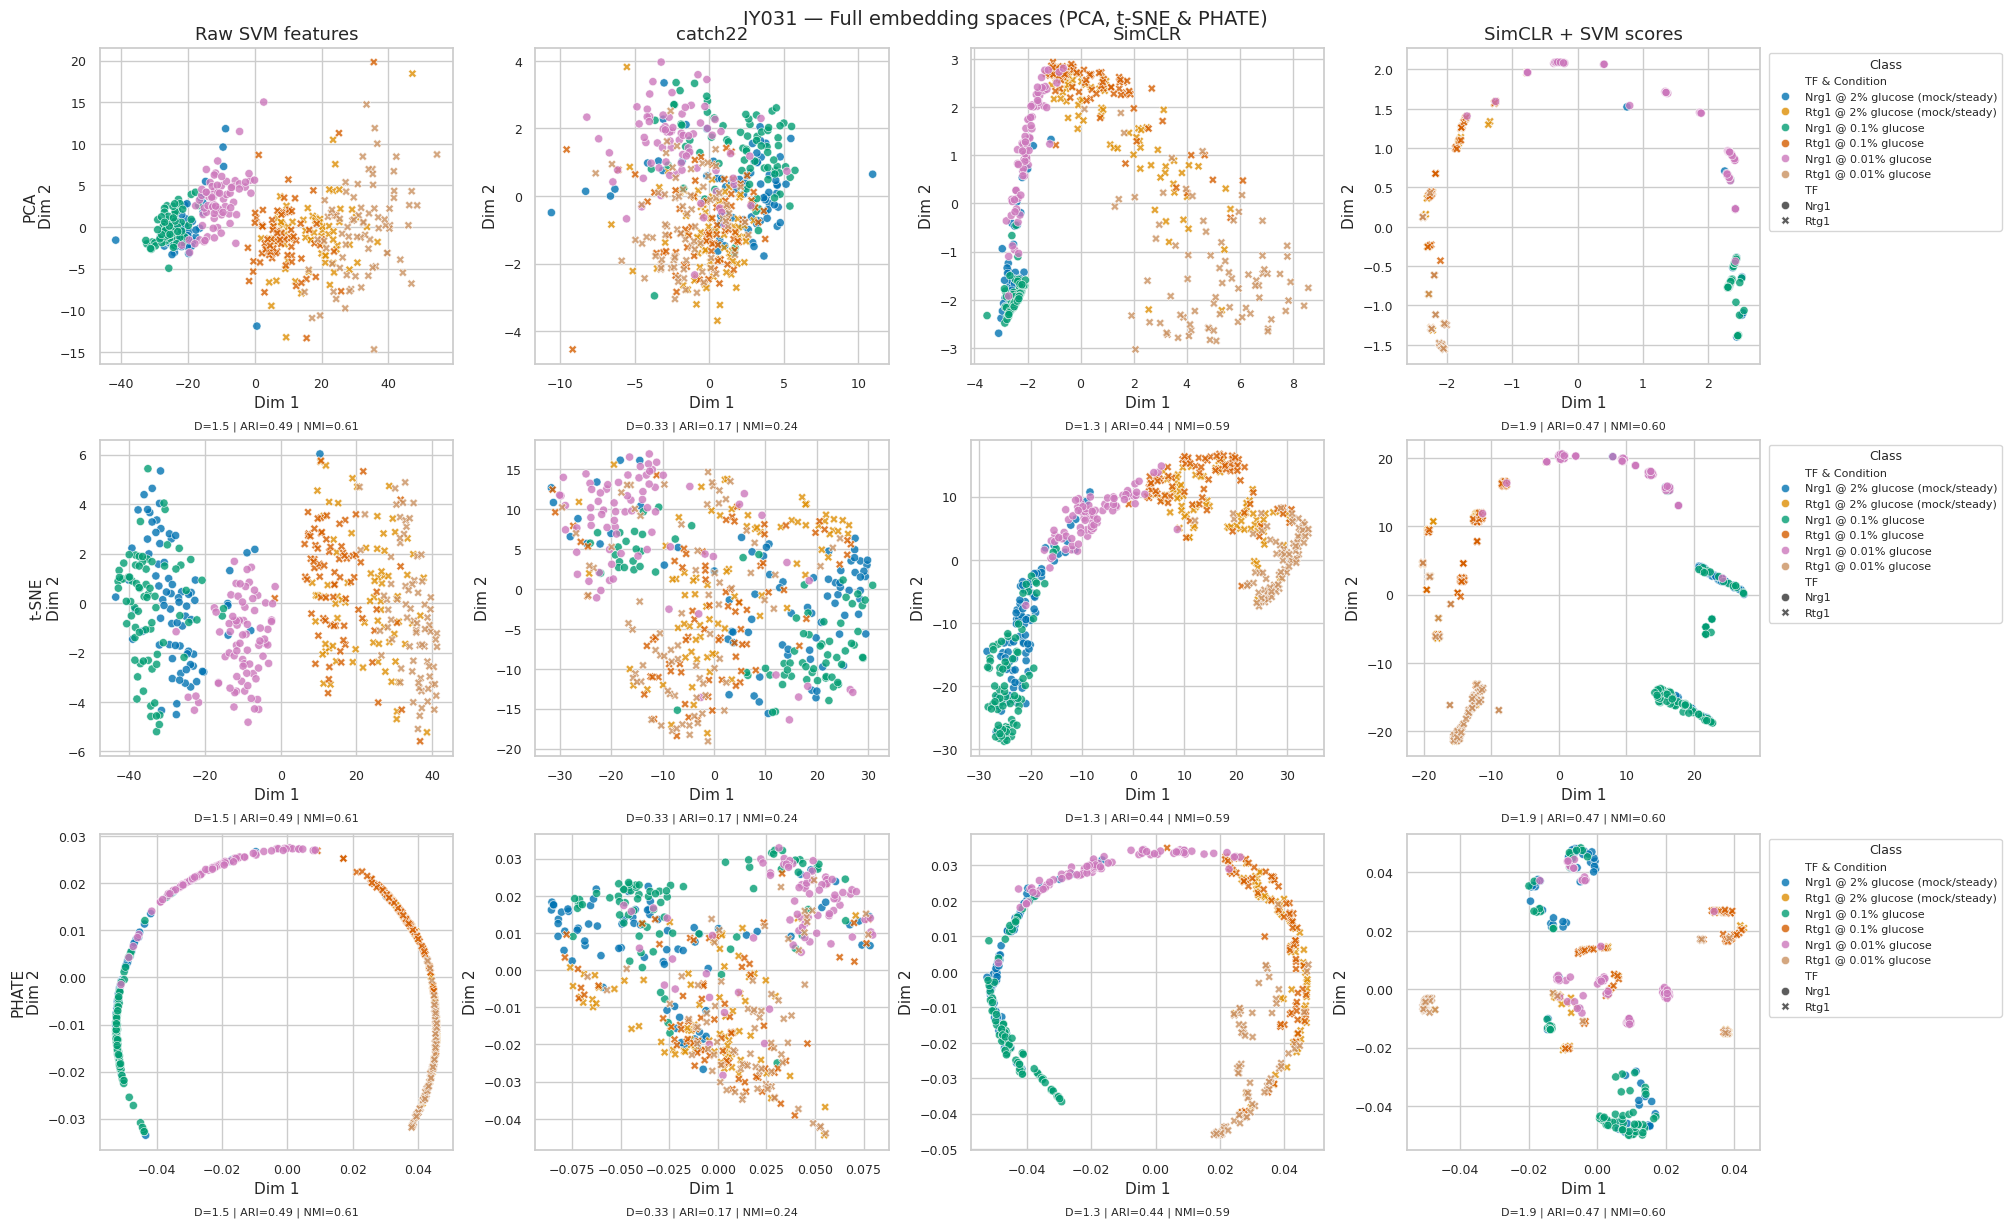

In [10]:
from utils.embeddings import projection_frame

representation_order = ["Raw SVM features", "catch22", "SimCLR", "SimCLR + SVM scores"]
method_order = ["PCA", "t-SNE", "PHATE"]
palette = sns.color_palette("colorblind", 6)


def format_metric_value(v):
    """Format to 2 significant figures."""
    return np.format_float_positional(v, precision=2, unique=False, fractional=False, trim="k")


def metric_annotation(d_df, c_df, repr_name):
    """One-line D / ARI / NMI string for subplot annotation."""
    d_row = d_df.set_index("representation").loc[repr_name]
    c_row = c_df.set_index("representation").loc[repr_name]
    return (
        f"D={format_metric_value(d_row['D_score'])} | "
        f"ARI={format_metric_value(c_row['ARI'])} | "
        f"NMI={format_metric_value(c_row['NMI'])}"
    )


for ds_name, ds in datasets.items():
    meta = metadata_dict[ds_name]
    d_df = d_score_dfs[ds_name]
    c_df = cluster_dfs[ds_name]

    # Build one long plotting table for all representation × method combinations.
    plot_df = pd.concat(
        [
            projection_frame(projections[ds_name][r][m], meta, r, m)
            for r in representation_order
            for m in method_order
        ],
        ignore_index=True,
    )
    # Add IY031-specific display aliases used by seaborn hue/style.
    plot_df["TF & Condition"] = plot_df["class_name"]
    plot_df["TF"] = plot_df["tf"]

    n_rows, n_cols = len(method_order), len(representation_order)
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(5 * n_cols, 4 * n_rows),
        constrained_layout=True,
        squeeze=False,
    )

    for row, method in enumerate(method_order):
        for col, repr_name in enumerate(representation_order):
            ax = axes[row, col]
            df_sub = plot_df[
                (plot_df["representation"] == repr_name) & (plot_df["method"] == method)
            ]
            # Show legend only on the rightmost column to avoid repetition.
            show_legend = col == n_cols - 1
            sns.scatterplot(
                data=df_sub, x="x", y="y",
                hue="TF & Condition", style="TF",
                palette=palette, s=35, alpha=0.80, ax=ax,
                legend=show_legend,
            )
            # Representation name as column header (top row only).
            if row == 0:
                ax.set_title(repr_name, fontsize=13)
            # Method label as row prefix (leftmost column only).
            ax.set_ylabel(f"{method}\nDim 2" if col == 0 else "Dim 2", fontsize=11)
            ax.set_xlabel("Dim 1", fontsize=11)
            ax.tick_params(labelsize=9)
            # Metric annotation — D/ARI/NMI are identical across projection methods.
            ax.text(
                0.5, -0.18, metric_annotation(d_df, c_df, repr_name),
                transform=ax.transAxes, ha="center", va="top", fontsize=8,
            )
            if show_legend:
                ax.legend(
                    bbox_to_anchor=(1.01, 1), loc="upper left",
                    fontsize=8, title="Class", title_fontsize=9,
                )

    fig.suptitle(f"IY031 — {ds_name} embedding spaces (PCA, t-SNE & PHATE)", fontsize=14, y=1.01)
    tag = ds_tags[ds_name]
    out_path = IY031_DIR / f"IY031_{tag}_embedding_scatter.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {out_path}")
    plt.show()
    plt.close()

In [11]:
# Save projection coordinates for all representations and methods (PCA, t-SNE, PHATE)
for ds_name, ds in datasets.items():
    tag = ds_tags[ds_name]
    meta = metadata_dict[ds_name]
    frames = []
    for repr_name in repr_matrices[ds_name]:
        for method in ["PCA", "t-SNE", "PHATE"]:
            frame = projection_frame(projections[ds_name][repr_name][method], meta, repr_name, method)
            frames.append(frame)
    combined = pd.concat(frames, ignore_index=True)
    combined["TF & Condition"] = combined["class_name"]
    combined["TF"] = combined["tf"]
    out_path = IY031_DIR / f"IY031_{tag}_embedding_coordinates.csv"
    combined.to_csv(out_path, index=False)
    print(f"Saved: {out_path}")
display(combined.head())

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY031/IY031_ss_embedding_coordinates.csv
Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY031/IY031_full_embedding_coordinates.csv


,class_name,label,tf,condition,x,y,representation,method,TF & Condition,TF
0,Nrg1 @ 2% glucose (mock/steady),2,Nrg1,2% glucose (mock/steady),-25.392348,-1.626876,Raw SVM features,PCA,Nrg1 @ 2% glucose (mock/steady),Nrg1
1,Nrg1 @ 2% glucose (mock/steady),2,Nrg1,2% glucose (mock/steady),-19.737070,-2.099478,Raw SVM features,PCA,Nrg1 @ 2% glucose (mock/steady),Nrg1
2,Nrg1 @ 2% glucose (mock/steady),2,Nrg1,2% glucose (mock/steady),-23.122878,-0.449388,Raw SVM features,PCA,Nrg1 @ 2% glucose (mock/steady),Nrg1
3,Nrg1 @ 2% glucose (mock/steady),2,Nrg1,2% glucose (mock/steady),-21.948694,-0.657089,Raw SVM features,PCA,Nrg1 @ 2% glucose (mock/steady),Nrg1
4,Nrg1 @ 2% glucose (mock/steady),2,Nrg1,2% glucose (mock/steady),-18.497894,-1.686429,Raw SVM features,PCA,Nrg1 @ 2% glucose (mock/steady),Nrg1
